<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [33]:
import sys

if 'google.colab' in sys.modules:
    print("Entorno Colab detectado. Asegurando instalación de librerias...")
    !pip install -q torchinfo

In [34]:
import os
import re
import requests
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
import torch.nn.functional as F

import json
import urllib
import matplotlib.pyplot as plt

import gradio as gr

In [35]:
# Configurar el dispositivo para PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"El dispositivo seleccionado es: {device}")

if device.type == 'cuda':
    print(f"Nombre de la GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Se está utilizando la CPU.")

El dispositivo seleccionado es: cuda
Nombre de la GPU: NVIDIA GeForce RTX 5070 Ti


### Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.

In [36]:
# Descarga el contenido del libro "El túnel" de Ernesto Sabato desde github

url = "https://raw.githubusercontent.com/mgonzalez738/desafios_procesamiento_lenguaje_natural/main/eltunel.txt"
filename = "eltunel.txt"

if not os.path.exists(filename):
    print(f"Archivo '{filename}' no encontrado. Descargando...")
    try:
        response = requests.get(url)
        response.raise_for_status()  # Verifica si la descarga fue exitosa
        with open(filename, "wb") as f:
            f.write(response.content)
        print("Descarga completada con éxito.")
    except Exception as e:
        print(f"Error al descargar: {e}")
else:
    print(f"El archivo '{filename}' ya existe en el directorio.")

El archivo 'eltunel.txt' ya existe en el directorio.


### Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.

In [37]:
# Obtiene todo el texto del libro.

tunel_text = ""

if os.path.exists(filename):
    with open(filename, "r", encoding="utf-8") as f:
        for line in f:
            # Usamos una expresión regular para limpiar el texto
            clean_line = re.sub(r"\\>", "", line)
            
            # Unimos al texto general eliminando saltos de línea innecesarios
            tunel_text += clean_line.strip() + " "

tunel_text = tunel_text.lower()
tunel_text = re.sub(r'\s+', ' ', tunel_text).strip()

print(f"\nInicio del texto [1000]:\n{tunel_text[:1000]}...")


Inicio del texto [1000]:
bastará decir que soy juan pablo castel, el pintor que mató a maría iribarne; supongo que el proceso está en el recuerdo de todos y que no se necesitan mayores explicaciones sobre mi persona. aunque ni el diablo sabe qué es lo que ha de recordar la gente, ni por qué. en realidad, siempre he pensado que no hay memoria colectiva, lo que quizá sea una forma de defensa de la especie humana. la frase "todo tiempo pasado fue mejor" no indica que antes sucedieran menos cosas malas, sino que —felizmente— la gente las echa en el olvido. desde luego, semejante frase no tiene validez universal; yo, por ejemplo, me caracterizo por recordar preferentemente los hechos malos y, así, casi podría decir que "todo tiempo pasado fue peor", si no fuera porque el presente me parece tan horrible como el pasado; recuerdo tantas calamidades, tantos rostros cínicos y crueles, tantas malas acciones, que la memoria es para mí como la temerosa luz que alumbra un sórdido museo de la vergüe

In [38]:
# Obtiene los caracteres únicos del texto y su cantidad (vocabulario).

chars_vocab = sorted(list(set(tunel_text)))
vocab_size = len(chars_vocab)

print(f"\nCantidad de caracteres únicos (vocabulario): {vocab_size}")

# Construye los dicionarios que asignan índices a caracteres y viceversa.

char2idx = {ch: i for i, ch in enumerate(chars_vocab)}
idx2char = {i: ch for i, ch in enumerate(chars_vocab)}

# Tokenización del texto completo
    
tokenized_text = [char2idx[ch] for ch in tunel_text]
print("Texto tokenizado [1000]:\n", tokenized_text[:1000])


Cantidad de caracteres únicos (vocabulario): 54
Texto tokenizado [1000]:
 [19, 18, 36, 37, 18, 35, 46, 0, 21, 22, 20, 26, 35, 0, 34, 38, 22, 0, 36, 32, 42, 0, 27, 38, 18, 31, 0, 33, 18, 19, 29, 32, 0, 20, 18, 36, 37, 22, 29, 5, 0, 22, 29, 0, 33, 26, 31, 37, 32, 35, 0, 34, 38, 22, 0, 30, 18, 37, 50, 0, 18, 0, 30, 18, 35, 48, 18, 0, 26, 35, 26, 19, 18, 35, 31, 22, 16, 0, 36, 38, 33, 32, 31, 24, 32, 0, 34, 38, 22, 0, 22, 29, 0, 33, 35, 32, 20, 22, 36, 32, 0, 22, 36, 37, 46, 0, 22, 31, 0, 22, 29, 0, 35, 22, 20, 38, 22, 35, 21, 32, 0, 21, 22, 0, 37, 32, 21, 32, 36, 0, 42, 0, 34, 38, 22, 0, 31, 32, 0, 36, 22, 0, 31, 22, 20, 22, 36, 26, 37, 18, 31, 0, 30, 18, 42, 32, 35, 22, 36, 0, 22, 41, 33, 29, 26, 20, 18, 20, 26, 32, 31, 22, 36, 0, 36, 32, 19, 35, 22, 0, 30, 26, 0, 33, 22, 35, 36, 32, 31, 18, 7, 0, 18, 38, 31, 34, 38, 22, 0, 31, 26, 0, 22, 29, 0, 21, 26, 18, 19, 29, 32, 0, 36, 18, 19, 22, 0, 34, 38, 47, 0, 22, 36, 0, 29, 32, 0, 34, 38, 22, 0, 25, 18, 0, 21, 22, 0, 35, 22, 20, 32, 35, 21,

In [39]:
max_context_size = 100 # Longitud de la secuencia de entrada (contexto)
batch_size = 256       # Tamaño del batch para entrenamiento

# Crea el dataset de entrenamiento con secuencias de max_context_size caracteres y su siguiente carácter como etiqueta.

class TextDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        # Entrada: secuencia de tokens
        x = torch.tensor(self.data[idx : idx + self.seq_len])
        # Target: secuencia desplazada una posición
        y = torch.tensor(self.data[idx + 1 : idx + self.seq_len + 1])
        return x, y

# División entrenamiento/validación (80/20)

split = int(len(tokenized_text) * 0.8)
train_ds = TextDataset(tokenized_text[:split], max_context_size)
val_ds = TextDataset(tokenized_text[split:], max_context_size)

# Crea los DataLoaders para entrenamiento y validación

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size)

### Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.

#### Arquitectura SimpleRNN

In [40]:
# Define el modelo RNN simple con una capa RNN y una capa densa de salida.
# La capa RNN tiene crecibe como entrada un vector one-hot del tamaño del vocabulario por cada caracter
# y produce una representación oculta que se pasa a la capa densa para predecir el siguiente carácter. 

class SimpleRNNModel(nn.Module):
    def __init__(self, vocab_size, hidden_dim, n_layers=1):
        super().__init__()
        self.rnn = nn.RNN(vocab_size, hidden_dim, n_layers, batch_first=True, dropout=0.2)
        self.dense = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h=None):
        x_ohe = torch.nn.functional.one_hot(x, num_classes=vocab_size).float()
        out, h = self.rnn(x_ohe, h)
        return self.dense(out), h


rnn_hidden_state=256
rnn_layers = 2
simple_rnn_model = SimpleRNNModel(vocab_size, rnn_hidden_state, rnn_layers)

print(simple_rnn_model)
summary(simple_rnn_model, 
        input_size=(batch_size, max_context_size),
        dtypes=[torch.long],         
        device=device.type)
   

SimpleRNNModel(
  (rnn): RNN(54, 256, num_layers=2, batch_first=True, dropout=0.2)
  (dense): Linear(in_features=256, out_features=54, bias=True)
)


Layer (type:depth-idx)                   Output Shape              Param #
SimpleRNNModel                           [256, 100, 54]            --
├─RNN: 1-1                               [256, 100, 256]           211,456
├─Linear: 1-2                            [256, 100, 54]            13,878
Total params: 225,334
Trainable params: 225,334
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 5.42
Input size (MB): 0.20
Forward/backward pass size (MB): 63.49
Params size (MB): 0.90
Estimated Total Size (MB): 64.59

#### Arquitectura LSTM

In [41]:
# Define el modelo LSTM con una capa LSTM y una capa densa de salida.

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, hidden_dim, n_layers=1):
        super().__init__()
        drop_prob = 0.2 if n_layers > 1 else 0.0   # Si hay 1 capa, el dropout debe ser 0 para evitar warnings de PyTorch
        self.lstm = nn.LSTM(vocab_size, hidden_dim, n_layers, batch_first=True, dropout=drop_prob)
        self.dense = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h=None):
        x_ohe = torch.nn.functional.one_hot(x, num_classes=vocab_size).float()
        out, h = self.lstm(x_ohe, h)
        return self.dense(out), h

lstm_hidden_state=256
lstm_layers = 2
lstm_model = LSTMModel(vocab_size, lstm_hidden_state, lstm_layers).to(device)

print(lstm_model)
summary(lstm_model, 
        input_size=(batch_size, max_context_size),
        dtypes=[torch.long],         
        device=device.type)

LSTMModel(
  (lstm): LSTM(54, 256, num_layers=2, batch_first=True, dropout=0.2)
  (dense): Linear(in_features=256, out_features=54, bias=True)
)


Layer (type:depth-idx)                   Output Shape              Param #
LSTMModel                                [256, 100, 54]            --
├─LSTM: 1-1                              [256, 100, 256]           845,824
├─Linear: 1-2                            [256, 100, 54]            13,878
Total params: 859,702
Trainable params: 859,702
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 21.66
Input size (MB): 0.20
Forward/backward pass size (MB): 63.49
Params size (MB): 3.44
Estimated Total Size (MB): 67.13

#### Arquitectura GRU

In [42]:
# Define el modelo GRU con una capa GRU y una capa densa de salida.

class GRUModel(nn.Module):
    def __init__(self, vocab_size, hidden_dim, n_layers=1):
        super().__init__()
        drop_prob = 0.2 if n_layers > 1 else 0.0
        self.gru = nn.GRU(vocab_size, hidden_dim, n_layers, batch_first=True, dropout=drop_prob)
        self.dense = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h=None):
        x_ohe = torch.nn.functional.one_hot(x, num_classes=vocab_size).float()
        out, h = self.gru(x_ohe, h)
        return self.dense(out), h

gru_hidden_state=256
gru_layers = 2
gru_model = GRUModel(vocab_size, gru_hidden_state, gru_layers).to(device)

print(gru_model)
summary(gru_model, 
        input_size=(batch_size, max_context_size),
        dtypes=[torch.long],         
        device=device.type)

GRUModel(
  (gru): GRU(54, 256, num_layers=2, batch_first=True, dropout=0.2)
  (dense): Linear(in_features=256, out_features=54, bias=True)
)


Layer (type:depth-idx)                   Output Shape              Param #
GRUModel                                 [256, 100, 54]            --
├─GRU: 1-1                               [256, 100, 256]           634,368
├─Linear: 1-2                            [256, 100, 54]            13,878
Total params: 648,246
Trainable params: 648,246
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 16.24
Input size (MB): 0.20
Forward/backward pass size (MB): 63.49
Params size (MB): 2.59
Estimated Total Size (MB): 66.29

#### Función de entrenamiento

In [43]:
  # Función de entrenamiento genérica

def train_model(model, optimizer, criterion, epochs=20, patience=5):
    
    model = model.to(device)
    history_ppl = []  
    best_ppl = float('inf')
    epochs_without_improvement = 0
    
    for epoch in range(epochs):

        # Entrenamiento
        
        model.train()
        for x, y in train_loader:
            if x.size(0) != batch_size: continue     # Descarta el último lote si quedó por la mitad
            x, y = x.to(device), y.to(device)
            model.zero_grad()
            output, _ = model(x, None)
            loss = criterion(output.transpose(1, 2), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            
        # Validación

        model.eval()
        val_loss = 0
        with torch.no_grad():
            lotes_validos = 0
            for x_v, y_v in val_loader:
                if x_v.size(0) != batch_size: continue
                x_v, y_v = x_v.to(device), y_v.to(device)
                out_v, _ = model(x_v, None)
                val_loss += criterion(out_v.transpose(1, 2), y_v).item()
                lotes_validos += 1
        
        avg_val_loss = val_loss / lotes_validos 
        perplexity = np.exp(avg_val_loss)
        history_ppl.append(perplexity) 
        
        print(f"Época {epoch+1:02d} | Valor de Perplejidad: {perplexity:.4f}")

        # Lógica Early Stopping

        if perplexity < best_ppl:
            best_ppl = perplexity
            epochs_without_improvement = 0
            torch.save(model.state_dict(), f'best_{model.__class__.__name__}.pth')
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print("Finalizado por Early Stopping.")
                break
                
    return history_ppl


Entrenando SimpleRNN:
Época 01 | Valor de Perplejidad: 9.3769
Época 02 | Valor de Perplejidad: 7.7227
Época 03 | Valor de Perplejidad: 6.8187
Época 04 | Valor de Perplejidad: 6.2167
Época 05 | Valor de Perplejidad: 5.8111
Época 06 | Valor de Perplejidad: 5.4756
Época 07 | Valor de Perplejidad: 5.2477
Época 08 | Valor de Perplejidad: 5.0853
Época 09 | Valor de Perplejidad: 4.9682
Época 10 | Valor de Perplejidad: 4.8837
Época 11 | Valor de Perplejidad: 4.8220
Época 12 | Valor de Perplejidad: 4.7744
Época 13 | Valor de Perplejidad: 4.7575
Época 14 | Valor de Perplejidad: 4.7319
Época 15 | Valor de Perplejidad: 4.7277
Época 16 | Valor de Perplejidad: 4.7174
Época 17 | Valor de Perplejidad: 4.7191
Época 18 | Valor de Perplejidad: 4.7377
Época 19 | Valor de Perplejidad: 4.7501
Época 20 | Valor de Perplejidad: 4.7823
Época 21 | Valor de Perplejidad: 4.7828
Finalizado por Early Stopping.

Entrenando LSTM:
Época 01 | Valor de Perplejidad: 18.1348
Época 02 | Valor de Perplejidad: 13.1193
Época 0

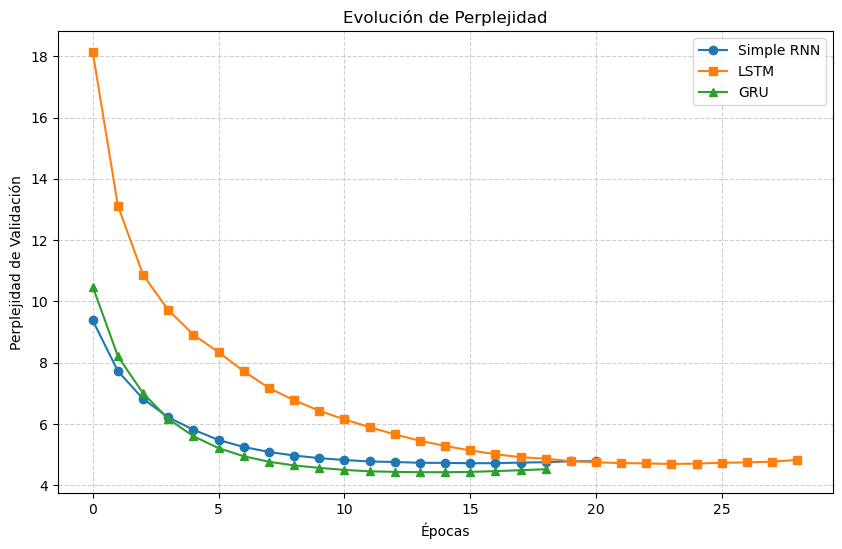

In [ ]:
# Entrenar o descargar modelos y comparar resultados

TRAIN = False    # Cambia a True para volver a entrenar
GITHUB_RAW_URL = "https://raw.githubusercontent.com/mgonzalez738/desafios_procesamiento_lenguaje_natural/main/"

if TRAIN:

    # Define función de pérdida (la misma para todos)
    criterion = nn.CrossEntropyLoss()
    lr = 0.0001

    # Entrena SimpleRNN
    print("Entrenando SimpleRNN:")
    optimizer_rnn = torch.optim.RMSprop(simple_rnn_model.parameters(), lr=lr)
    hist_rnn =train_model(simple_rnn_model, optimizer_rnn, criterion, epochs=50)

    # Entrena LSTM
    print("\nEntrenando LSTM:")
    optimizer_lstm = torch.optim.RMSprop(lstm_model.parameters(), lr=lr)
    hist_lstm = train_model(lstm_model, optimizer_lstm, criterion, epochs=50)

    # Entrena GRU
    print("\nEntrenando GRU:")
    optimizer_gru = torch.optim.RMSprop(gru_model.parameters(), lr=lr)
    hist_gru = train_model(gru_model, optimizer_gru, criterion, epochs=50)

    # Guarda evolucion entrenamientos en un archivo JSON para futuras referencias
    historias = {
        'rnn': hist_rnn,
        'lstm': hist_lstm,
        'gru': hist_gru
    }
    with open('historial_perplejidad.json', 'w') as f:
        json.dump(historias, f)
    print("\nEntrenamiento finalizado. Archivos de modelos .pth e historial_perplejidad.json guardados.")

else:

    print("Descargando modelos entrenados desde GitHub")
    
    archivos_a_descargar = [
        'best_SimpleRNNModel.pth',
        'best_LSTMModel.pth',
        'best_GRUModel.pth',
        'historial_perplejidad.json'
    ]
    
    for archivo in archivos_a_descargar:
        url = GITHUB_RAW_URL + archivo
        if not os.path.exists(archivo):
            print(f"Descargando {archivo}...")
            try:
                urllib.request.urlretrieve(url, archivo)
            except Exception as e:
                print(f"Advertencia: No se pudo descargar {archivo}. Error: {e}")
        else:
            print(f"El archivo {archivo} ya existe localmente.")

    # Carga los pesos en los modelos (map_location=device asegura que funcione en CPU o GPU)
    if os.path.exists('best_SimpleRNNModel.pth'):
        simple_rnn_model.load_state_dict(torch.load('best_SimpleRNNModel.pth', map_location=device))
        
    if os.path.exists('best_LSTMModel.pth'):
        lstm_model.load_state_dict(torch.load('best_LSTMModel.pth', map_location=device))
        
    if os.path.exists('best_GRUModel.pth'):
        gru_model.load_state_dict(torch.load('best_GRUModel.pth', map_location=device))
    
    # Carga la evolucion de la perplejidad desde el archivo JSON
    if os.path.exists('historial_perplejidad.json'):
        with open('historial_perplejidad.json', 'r') as f:
            historias = json.load(f)
        hist_rnn = historias.get('rnn', [])
        hist_lstm = historias.get('lstm', [])
        hist_gru = historias.get('gru', [])
    else:
        print("No se encontró el archivo de historial. No se podrá graficar.")
        hist_rnn, hist_lstm, hist_gru = [], [], []

# Grafica evolucion perplejidad

if hist_rnn and hist_lstm and hist_gru:
    plt.figure(figsize=(10, 6))
    plt.plot(hist_rnn, label='Simple RNN', marker='o')
    plt.plot(hist_lstm, label='LSTM', marker='s')
    plt.plot(hist_gru, label='GRU', marker='^')

    plt.title('Evolución de Perplejidad')
    plt.xlabel('Épocas')
    plt.ylabel('Perplejidad de Validación')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

### Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.

In [45]:
# Funciones de codificación y decodificación

# Convierte un texto de entrada en un tensor de índices utilizando el diccionario char2idx.

def encode(text, char2idx, max_length, device):
    encoded = [char2idx.get(ch, 0) for ch in text.lower()]
    tensor = torch.tensor(encoded, dtype=torch.long, device=device)
    
    # Solo truncamos si es excesivamente largo
    if tensor.size(0) > max_length:
        tensor = tensor[-max_length:]
        
    return tensor.unsqueeze(0) 

# Convierte un tensor de índices de vuelta a texto.

def decode(seq, idx2char):
    if torch.is_tensor(seq):
        seq = seq.tolist()
    return ''.join([idx2char[ch] for ch in seq if ch in idx2char])

In [46]:
# Función de generación de texto utilizando búsqueda greedy search.
# A partir de un texto semilla, genera n_words caracteres adicionales utilizando el modelo entrenado

def greedy_search(model, seed_text, n_words, max_context, char2idx, idx2char, device, temp=1.0):
    model.eval()
    out_text = seed_text
    
    with torch.no_grad():
        for _ in range(n_words):
            
            # Codifica el texto actual (últimos max_context caracteres) a tensor de índices
            x = encode(out_text, char2idx, max_context, device)      
            
            # Genera la predicción del siguiente carácter
            out, _ = model(x, None)
            logits = out[0, -1, :] 
            
            # Selección (Determinista vs Estocástica)
            if temp == 0.0:
                # Determinista puro (equivale a np.argmax)
                siguiente_idx = torch.argmax(logits).item()
            else:
                # Estocástico (afectado por la temperatura)
                probs = F.softmax(logits / temp, dim=0)
                siguiente_idx = torch.multinomial(probs, 1).item()
                
            out_text += idx2char[siguiente_idx]
            
    return out_text

In [47]:
# Función de generación de texto utilizando búsqueda beam search.

def beam_search(model, seed_text, num_beams, num_words, max_context, char2idx, idx2char, device, temp=1.0, mode='det'):
    model.eval()
    vocab_size = len(char2idx)
    
    with torch.no_grad():
        
        # Codifica el texto semilla para obtener la primera predicción y establecer el historial inicial de beams
        x = encode(seed_text, char2idx, max_context, device)
        out, _ = model(x, None)
        logits = out[0, -1, :]
        log_probs = F.log_softmax(logits, dim=0)
        
        if mode == 'det':
            # Para la primera iteración, simplemente toma los top-k caracteres para iniciar los beams
            history_probs, next_chars = torch.topk(log_probs, num_beams)
        elif mode == 'sto':
            # Aplica temperatura y muestrea los primeros caracteres para iniciar los beams
            probs = F.softmax(logits / temp, dim=0)
            next_chars = torch.multinomial(probs, num_beams, replacement=True)
            history_probs = log_probs[next_chars]
        else:
            raise ValueError("mode debe ser 'det' o 'sto'")

        # Inicializ el historial para todos los beams.
        history_tokens = x.repeat(num_beams, 1)
        history_tokens = torch.cat([history_tokens, next_chars.unsqueeze(1)], dim=1)

        # Bucle principal de generación para los siguientes caracteres
        for _ in range(num_words - 1):
            # Toma solo el contexto máximo permitido para no desbordar el modelo
            input_seq = history_tokens[:, -max_context:] 
            
            # Pasa todos los beams al modelo de una sola vez
            out, _ = model(input_seq, None)
            logits = out[:, -1, :] # Shape: [num_beams, vocab_size]
            
            log_probs = F.log_softmax(logits, dim=1)
            
            # Suma las probabilidades históricas a las nuevas probabilidades
            total_log_probs = history_probs.unsqueeze(1) + log_probs 
            
            # Aplana para buscar los mejores entre todas las ramas juntas
            flat_log_probs = total_log_probs.view(-1) 
            
            if mode == 'det':
                top_probs, top_indices = torch.topk(flat_log_probs, num_beams)
            elif mode == 'sto':
                probs = F.softmax(total_log_probs.view(-1) / temp, dim=0)
                top_indices = torch.multinomial(probs, num_beams, replacement=True)
                top_probs = flat_log_probs[top_indices]
            
            # Reconstruye los índices (qué rama y qué caracter ganó)
            beam_indices = top_indices // vocab_size
            char_indices = top_indices % vocab_size
            
            # Actualiza el historial usando solo las ramas ganadoras
            history_probs = top_probs
            history_tokens = torch.cat([history_tokens[beam_indices], char_indices.unsqueeze(1)], dim=1)

    # Extrae solo el texto generado de la mejor rama (la primera)
    mejor_secuencia = history_tokens[0]
    return decode(mejor_secuencia, idx2char)

In [48]:
# Función que recibe el texto semilla, la estrategia de generación y la temperatura, y devuelve el texto generado por el modelo GRU.

def model_response(human_text, metodo, temperatura):
    try:
        if metodo == "Greedy Determinista":
            resultado = greedy_search(gru_model, human_text, n_words=30, max_context=100, 
                                      char2idx=char2idx, idx2char=idx2char, device=device, temp=0.0)
        
        elif metodo == "Greedy Estocástico":
            resultado = greedy_search(gru_model, human_text, n_words=30, max_context=100, 
                                      char2idx=char2idx, idx2char=idx2char, device=device, temp=temperatura)
            
        elif metodo == "Beam Search Determinista":
            resultado = beam_search(gru_model, human_text, num_beams=10, num_words=30, max_context=100, 
                                    char2idx=char2idx, idx2char=idx2char, device=device, mode='det')
            
        elif metodo == "Beam Search Estocástico":
            resultado = beam_search(gru_model, human_text, num_beams=10, num_words=30, max_context=100, 
                                    char2idx=char2idx, idx2char=idx2char, device=device, temp=temperatura, mode='sto')
        
        return resultado
    except Exception as e:
        return f"Error en la generación: {str(e)}"

# Interfaz para poder modificar los hiperparámetros

iface = gr.Interface(
    fn=model_response,
    inputs=[
        gr.Textbox(label="Texto semilla (Ej: 'había una vez')"),
        gr.Dropdown(["Greedy Determinista", "Greedy Estocástico", "Beam Search Determinista", "Beam Search Estocástico"], label="Estrategia", value="Beam Search Estocástico"),
        gr.Slider(minimum=0.1, maximum=2.0, value=0.8, step=0.1, label="Temperatura (Solo estocástico)")
    ],
    outputs=gr.Textbox(label="Texto Generado"),
    title="Generador de Texto - El Túnel (Modelo GRU)"
)

iface.launch(debug=True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Keyboard interruption in main thread... closing server.


### Análisis de Resultados

Se implementaron los modelos SimpleRNN, LSTM y GRU utilizando PyTorch. Para ello, se preparó un dataset de entrenamiento basado en el libro El Túnel. Tras entrenar las tres arquitecturas, el modelo GRU mostró un mejor desempeño, logrando niveles de perplejidad ligeramente inferiores al resto. Finalmente, se generaron nuevas secuencias utilizando las estrategias Greedy Search y Beam Search, tanto en sus variantes determinísticas como estocásticas.

Particularmente, resulta interesante observar el efecto del hiperparámetro de temperatura (T) durante la generación con Beam Search estocástico. Partiendo de la semilla "a la tarde en la playa":

- Para valores bajos (T = 0.1): El modelo se vuelve conservador y genera mayormente la misma secuencia repetitiva: "a la tarde en la playa saber que ella no había pensa".

- Para valores altos (T = 2.0): La aleatoriedad excesiva produce secuencias incoherentes o palabras sin sentido: "a la tarde en la playa has al pisamente. —no sé qué".

- Para valores intermedios (T ≈ 0.8): Se logra un equilibrio ideal, obteniendo secuencias variadas, creativas y con palabras reales coherentes:

    - "a la tarde en la playa saber que no había pensado en"

    - "a la tarde en la playa que no era una carta de la mu"

    - "a la tarde en la playa sobre todo lo que había dicho"
   
